In [378]:
from pctk import multicellds
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io

from scipy.interpolate import griddata

In [373]:
mcds_reader = multicellds.MultiCellDS("../output/")
vol_idx = 4
name2idx = {n:i for i,n in enumerate(mcds_reader.cell_columns)}

data = []
for t, a in mcds_reader.microenvironment_as_matrix_iterator():
    data.append((t/60., (a[5].sum() / len(a[5])), (a[6].sum() / len(a[6])), (a[4].sum() / len(a[4])) ))

df_substrates = pd.DataFrame(data=data, columns=["time", "glucose", "acetate", "oxygen"]).set_index("time")

data = []
for t, a in mcds_reader.cells_as_matrix_iterator():
    total_volume = a[:,4].sum() # um3
    scaled_volume = total_volume / 10**12 # mL
    density = 1.04 # g/ml
    solid_fraction = 0.25
    biomass = scaled_volume * density * solid_fraction / 2e-8 
    #print("total volume is ", total_volume)
    
    data.append((t/60, a.shape[0], a[:,-2].max(), a[:,-1].max(), biomass, a[:,-4].mean(), a[:,-5].mean()))

df_cells = pd.DataFrame(data=data, columns=["time", "n_cells", "growth_rate", "growth_factor", "total_biomass", "acetate", "glucose"])

Text(0.5, 0, 'Time (hours)')

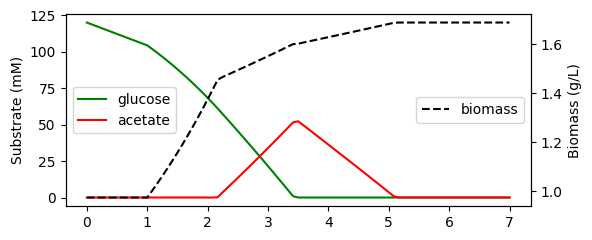

In [374]:
fig, ax = plt.subplots(1,1,figsize=(6,2.5), sharex=True)
s = "glucose"
ax.plot(df_substrates[s], label=s, c='g')
s = "acetate"
ax.plot(df_substrates[s], label=s, c='r')
ax.legend(loc=6)
ax.set_ylabel("Substrate (mM)")
ax = ax.twinx()
ax.plot(df_cells['time'], df_cells['total_biomass'], 'k--', label="biomass")
ax.set_ylabel("Biomass (g/L)")
ax.legend(loc=5)
ax.set_xlabel("Time (hours)")

Text(0, 0.5, 'Exchange flux')

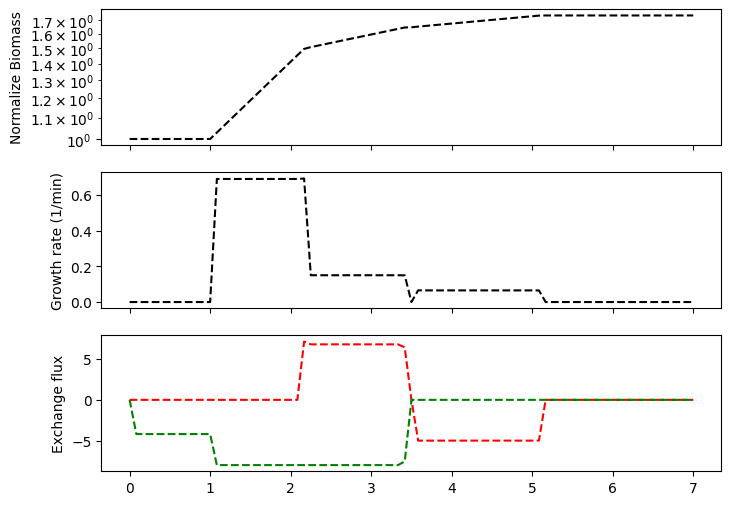

In [377]:
fig, axes = plt.subplots(3,1,figsize=(8,6), sharex=True)

ax = axes[0]
ax.plot(df_cells['time'], df_cells['total_biomass']/df_cells.loc[0, 'total_biomass'], 'k--')
ax.set_yscale('log')
ax.set_ylabel("Normalize Biomass")

ax = axes[1]
ax.plot(df_cells['time'], df_cells['growth_rate'], 'k--')
ax.set_ylabel("Growth rate (1/min)")


ax = axes[2]
ax.plot(df_cells['time'], df_cells['acetate'], 'r--', label="acetate")
ax.plot(df_cells['time'], df_cells['glucose'], 'g--', label="glucose")
ax.set_ylabel("Exchange flux")

In [254]:
mask = df_cells["growth_rate"] > 0

df = df_cells.loc[mask, ["growth_rate", "growth_factor"]]

df['test'] = np.exp(df["growth_rate"]/60. * 0.01)

df

,growth_rate,growth_factor,test
7,0.690506,1.000115,1.000115
8,0.690502,1.000115,1.000115
9,0.690497,1.000115,1.000115
10,0.690492,1.000115,1.000115
11,0.690486,1.000115,1.000115
12,0.690479,1.000115,1.000115
13,0.690469,1.000115,1.000115
14,0.692664,1.000115,1.000115
15,0.448690,1.000075,1.000075
16,0.271383,1.000045,1.000045


In [293]:
M

array([[-240.        , -220.        , -200.        , ...,  200.        ,
         220.        ,  240.        ],
       [-240.        , -240.        , -240.        , ...,  240.        ,
         240.        ,  240.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [ 117.40546851,  117.40468053,  117.40313693, ...,  117.43154777,
         117.43255443,  117.43307008],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
           0.        ,    0.        ]], shape=(8, 625))

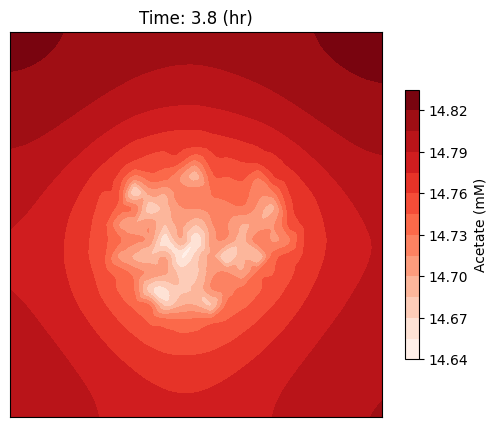

In [397]:


# Load one time step
step = 45
time = step * 5 / 60
mat = scipy.io.loadmat(f"../output/output000000{step:2}_microenvironment0.mat")
M = mat["multiscale_microenvironment"]

x = M[0,:]
y = M[1,:]
z = M[2,:]
substrate = M[6,:] / 3  # usually the first substrate, check your XML
# substrate[0] = 0.1
substrate_name = "Acetate"

# Determine grid size
nx = len(np.unique(x))
ny = len(np.unique(y))


xi = np.linspace(x.min(), x.max(), 200)  # finer grid
yi = np.linspace(y.min(), y.max(), 200)
Xi, Yi = np.meshgrid(xi, yi)

from scipy.interpolate import griddata
Zi = griddata((x, y), substrate, (Xi, Yi), method='cubic')  # smooth interpolation

fig,ax = plt.subplots(1,1,figsize=(6,5))
im = ax.contourf(Xi, Yi, Zi, levels=15, cmap='Reds')
plt.colorbar(im, label=f'{substrate_name} (mM)', ax=ax, shrink=0.7)
ax.set_title(f'Time: {time:.1f} (hr)')
ax.set_xticks([])
ax.set_yticks([])

fig.savefig(f"../figs/{substrate_name}_{time:.1f}h.svg")